In [ ]:
import pandas as pd
import numpy as np
import warnings
from time import time
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, RepeatedStratifiedKFold
from scipy.stats import randint, loguniform
from sklearn.neural_network import MLPClassifier
from sklearn import svm
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, mean_squared_error, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

wine_data = pd.read_csv('winequality-red.csv', sep=';')


print("--- Initial Data Overview ---")
print("\nFirst 5 Rows:")
print(wine_data.head())

print(f"\nDataset Shape: {wine_data.shape}")

print("\nDataset Info:")
wine_data.info()

print("\nDescriptive Statistics:")
print(wine_data.describe())

X = wine_data.drop('quality', axis=1)
y = wine_data['quality']

print("\n--- Data Preparation ---")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Unique target values: {sorted(y.unique())}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=5, stratify=y
)

print("\n--- Data Splitting ---")
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

--- Initial Data Overview ---

First 5 Rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5

In [ ]:
pipeline = Pipeline(
    steps=[("preprocess", StandardScaler()),
           ("classify", svm.SVC(random_state=5))]
)

model_params = {'classify__decision_function_shape': ['ovo','ovr'],
                'classify__C': loguniform(1e-3, 1e3),
                'classify__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
                'classify__degree': randint(2, 5),
                'classify__gamma': loguniform(1e-4, 1e1)
               }

n_iter = 20
random_search = RandomizedSearchCV(pipeline,
                                   param_distributions=model_params,
                                   n_iter=n_iter, verbose=3)

random_search.fit(X_train, y_train)

print(f"Best parameters: {random_search.best_params_}")
print(f"Best cross-validation score: {random_search.best_score_}")
svm_best = random_search.best_estimator_

print(f"Training accuracy = {svm_best.score(X_train, y_train)}")
print('Training Classification Report')
print(classification_report(y_train, svm_best.predict(X_train)))
print('Test Confusion Matrix')
ConfusionMatrixDisplay.from_estimator(svm_best, X_train, y_train)
plt.show()

print(f"Test accuracy = {svm_best.score(X_test, y_test)}")
print('Test Classification Report')
print(classification_report(y_test, svm_best.predict(X_test)))
print('Test Confusion Matrix')
ConfusionMatrixDisplay.from_estimator(svm_best, X_test, y_test)
plt.show()

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END classify__C=116.2544991118791, classify__decision_function_shape=ovo, classify__degree=2, classify__gamma=0.013630814295221883, classify__kernel=poly;, score=0.545 total time=   0.0s
[CV 2/5] END classify__C=116.2544991118791, classify__decision_function_shape=ovo, classify__degree=2, classify__gamma=0.013630814295221883, classify__kernel=poly;, score=0.540 total time=   0.0s
[CV 3/5] END classify__C=116.2544991118791, classify__decision_function_shape=ovo, classify__degree=2, classify__gamma=0.013630814295221883, classify__kernel=poly;, score=0.545 total time=   0.0s
[CV 4/5] END classify__C=116.2544991118791, classify__decision_function_shape=ovo, classify__degree=2, classify__gamma=0.013630814295221883, classify__kernel=poly;, score=0.522 total time=   0.0s
[CV 5/5] END classify__C=116.2544991118791, classify__decision_function_shape=ovo, classify__degree=2, classify__gamma=0.013630814295221883, classify__ker

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END classify__activation=relu, classify__alpha=0.0007197913503766693, classify__hidden_layer_sizes=(100,), classify__solver=sgd;, score=0.607 total time=   1.8s
[CV 2/5] END classify__activation=relu, classify__alpha=0.0007197913503766693, classify__hidden_layer_sizes=(100,), classify__solver=sgd;, score=0.580 total time=   1.6s
[CV 3/5] END classify__activation=relu, classify__alpha=0.0007197913503766693, classify__hidden_layer_sizes=(100,), classify__solver=sgd;, score=0.603 total time=   2.3s
[CV 4/5] END classify__activation=relu, classify__alpha=0.0007197913503766693, classify__hidden_layer_sizes=(100,), classify__solver=sgd;, score=0.576 total time=   2.4s
[CV 5/5] END classify__activation=relu, classify__alpha=0.0007197913503766693, classify__hidden_layer_sizes=(100,), classify__solver=sgd;, score=0.592 total time=   2.5s
[CV 1/5] END classify__activation=relu, classify__alpha=4.804869378858693, classify__hid

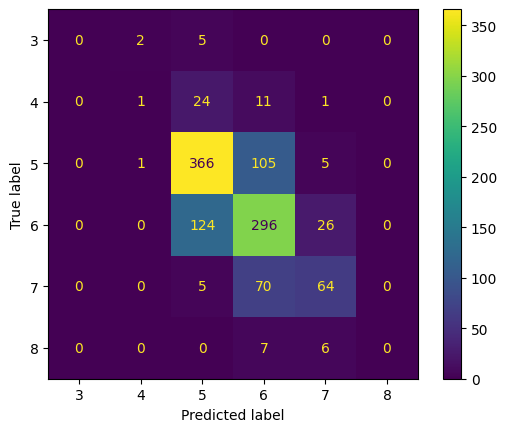

Test accuracy = 0.6
Test Classification Report
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        16
           5       0.66      0.74      0.70       204
           6       0.56      0.60      0.58       192
           7       0.49      0.37      0.42        60
           8       0.00      0.00      0.00         5

    accuracy                           0.60       480
   macro avg       0.29      0.28      0.28       480
weighted avg       0.57      0.60      0.58       480

Test Confusion Matrix


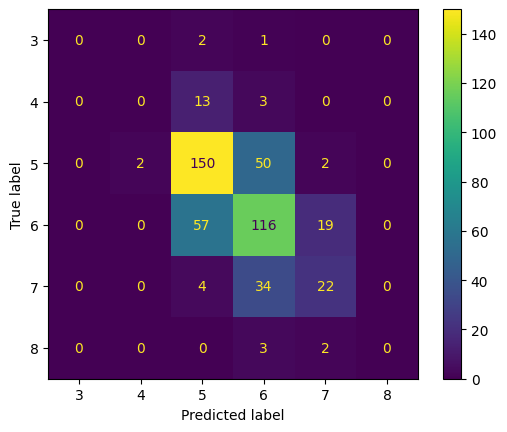

In [ ]:
pipeline = Pipeline(
    steps=[("preprocess", StandardScaler()),
           ("classify", MLPClassifier(max_iter=5000))]
)

model_params = {
    'classify__alpha': loguniform(1e-4, 10),
    'classify__solver': ['sgd','adam'],
    'classify__hidden_layer_sizes': [
        (100,),        
        (50, 25),      
        (32, 16, 8),     
        (64, 32)            
    ],
    'classify__activation': ['tanh','relu'] 
}

n_iter = 20
random_search = RandomizedSearchCV(pipeline,
                                   param_distributions=model_params, 
                                   n_iter=n_iter, verbose=3)

start = time()
random_search.fit(X_train, y_train)
print("RandomizedSearchCV took %.2f seconds for %d candidates parameter settings."
        % ((time() - start), n_iter))

print(random_search.best_params_)
print(random_search.best_estimator_)

mlp_classifier_best = random_search.best_estimator_

print(f"Training accuracy = {mlp_classifier_best.score(X_train, y_train)}")
print('Training Classification Report')
print(classification_report(y_train, mlp_classifier_best.predict(X_train)))
print('Test Confusion Matrix')
ConfusionMatrixDisplay.from_estimator(mlp_classifier_best, X_train, y_train)
plt.show()

print(f"Test accuracy = {mlp_classifier_best.score(X_test, y_test)}")
print('Test Classification Report')
print(classification_report(y_test, mlp_classifier_best.predict(X_test)))
print('Test Confusion Matrix')
ConfusionMatrixDisplay.from_estimator(mlp_classifier_best, X_test, y_test)
plt.show()

Training Classification Report
              precision    recall  f1-score   support

           3       1.00      1.00      1.00         7
           4       1.00      1.00      1.00        37
           5       1.00      1.00      1.00       477
           6       1.00      1.00      1.00       446
           7       1.00      1.00      1.00       139
           8       1.00      1.00      1.00        13

    accuracy                           1.00      1119
   macro avg       1.00      1.00      1.00      1119
weighted avg       1.00      1.00      1.00      1119

Training Confusion Matrix


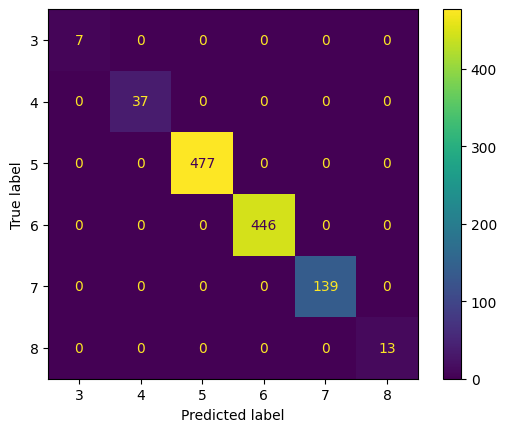

Test Classification Report
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        16
           5       0.72      0.80      0.76       204
           6       0.66      0.65      0.65       192
           7       0.59      0.57      0.58        60
           8       0.50      0.20      0.29         5

    accuracy                           0.67       480
   macro avg       0.41      0.37      0.38       480
weighted avg       0.65      0.67      0.66       480

Test Confusion Matrix


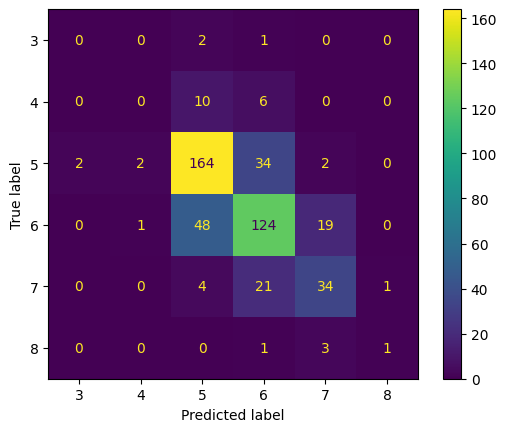

In [ ]:
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)
num_classes = len(label_encoder.classes_)
dtrain_clf = xgb.DMatrix(X_train, y_train_enc, enable_categorical=True)
dtest_clf = xgb.DMatrix(X_test, y_test_enc, enable_categorical=True)

params = {"objective": "multi:softprob", "num_class": num_classes}
n = 1000

model = xgb.train(
   params=params,
   dtrain=dtrain_clf,
   num_boost_round=n
)
results = xgb.cv(
   params, dtrain_clf,
   num_boost_round=n,
   nfold=5,
   metrics=["mlogloss", "auc", "merror"])

y_pred_train = model.predict(dtrain_clf)
y_pred_test = model.predict(dtest_clf)

y_pred_train_labels = label_encoder.inverse_transform(y_pred_train.argmax(axis=1))
y_pred_test_labels = label_encoder.inverse_transform(y_pred_test.argmax(axis=1))

print('Training Classification Report')
print(classification_report(y_train, y_pred_train_labels))
print('Training Confusion Matrix')
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train_labels)
plt.show()

print('Test Classification Report')
print(classification_report(y_test, y_pred_test_labels))
print('Test Confusion Matrix')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test_labels)
plt.show()

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END classify__learning_rate=0.48805629992957494, classify__max_depth=4, classify__min_samples_leaf=9, classify__min_samples_split=8, classify__n_estimators=199, classify__subsample=0.5281317971973909;, score=0.201 total time=   1.6s
[CV 2/5] END classify__learning_rate=0.48805629992957494, classify__max_depth=4, classify__min_samples_leaf=9, classify__min_samples_split=8, classify__n_estimators=199, classify__subsample=0.5281317971973909;, score=0.348 total time=   1.8s
[CV 3/5] END classify__learning_rate=0.48805629992957494, classify__max_depth=4, classify__min_samples_leaf=9, classify__min_samples_split=8, classify__n_estimators=199, classify__subsample=0.5281317971973909;, score=0.183 total time=   1.7s
[CV 4/5] END classify__learning_rate=0.48805629992957494, classify__max_depth=4, classify__min_samples_leaf=9, classify__min_samples_split=8, classify__n_estimators=199, classify__subsample=0.5281317971973909;, s

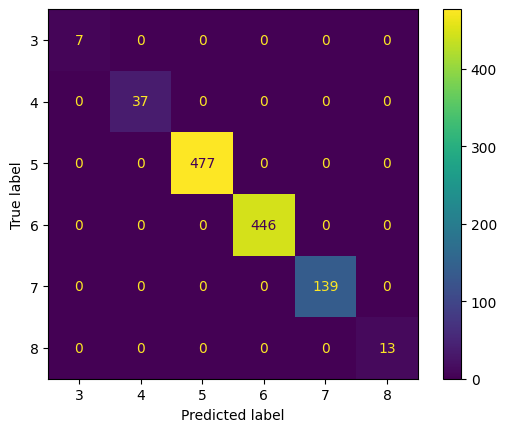

Test accuracy = 0.6854166666666667
Test Classification Report
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.50      0.06      0.11        16
           5       0.73      0.81      0.77       204
           6       0.65      0.67      0.66       192
           7       0.63      0.57      0.60        60
           8       1.00      0.20      0.33         5

    accuracy                           0.69       480
   macro avg       0.58      0.38      0.41       480
weighted avg       0.68      0.69      0.67       480

Test Confusion Matrix


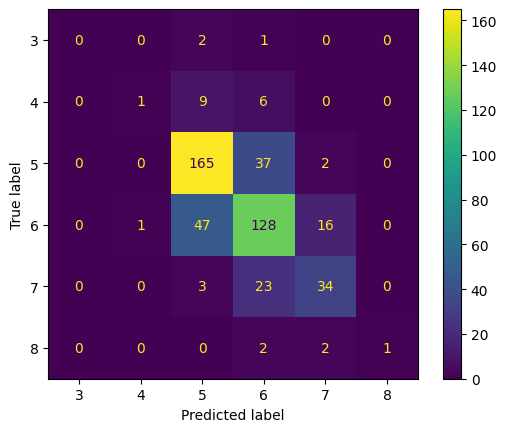

In [9]:
model_params = {'classify__n_estimators': randint(50, 500),
                'classify__learning_rate': loguniform(0.01, 1.0),
                'classify__max_depth': randint(2, 10),
                'classify__subsample': loguniform(0.5, 1.0),
                'classify__min_samples_split': randint(2, 10),
                'classify__min_samples_leaf': randint(1, 10)
               }

pipeline = Pipeline(
    steps=[("preprocess", StandardScaler()),
           ("classify", GradientBoostingClassifier(random_state=5))]
)

n_iter = 20
random_search = RandomizedSearchCV(pipeline,
                                     param_distributions=model_params, 
                                     n_iter=n_iter, verbose=3)

random_search.fit(X_train, y_train)

print(f"Best parameters: {random_search.best_params_}")
print(f"Best cross-validation score: {random_search.best_score_}")

gbc = random_search.best_estimator_

y_train_gbc = gbc.predict(X_train)
y_pred_gbc = gbc.predict(X_test)

print(f"Training accuracy = {gbc.score(X_train, y_train)}")
print('Training Classification Report')
print(classification_report(y_train, y_train_gbc, zero_division=0))
print('Training Confusion Matrix')
ConfusionMatrixDisplay.from_estimator(gbc, X_train, y_train)
plt.show()

print(f"Test accuracy = {gbc.score(X_test, y_test)}")
print('Test Classification Report')
print(classification_report(y_test, y_pred_gbc, zero_division=0))
print('Test Confusion Matrix')
ConfusionMatrixDisplay.from_estimator(gbc, X_test, y_test)
plt.show()

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV 1/5] END classify__max_depth=11, classify__n_estimators=61;, score=0.665 total time=   0.0s
[CV 2/5] END classify__max_depth=11, classify__n_estimators=61;, score=0.656 total time=   0.0s
[CV 3/5] END classify__max_depth=11, classify__n_estimators=61;, score=0.670 total time=   0.0s
[CV 4/5] END classify__max_depth=11, classify__n_estimators=61;, score=0.629 total time=   0.0s
[CV 5/5] END classify__max_depth=11, classify__n_estimators=61;, score=0.682 total time=   0.0s
[CV 1/5] END classify__max_depth=11, classify__n_estimators=375;, score=0.679 total time=   0.6s
[CV 2/5] END classify__max_depth=11, classify__n_estimators=375;, score=0.629 total time=   0.6s
[CV 3/5] END classify__max_depth=11, classify__n_estimators=375;, score=0.679 total time=   0.6s
[CV 4/5] END classify__max_depth=11, classify__n_estimators=375;, score=0.647 total time=   0.6s
[CV 5/5] END classify__max_depth=11, classify__n_estimators=375;, score=

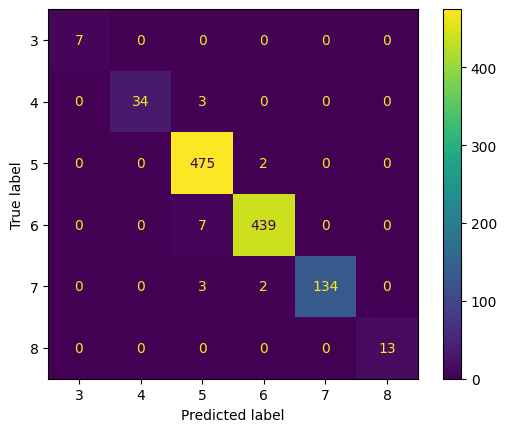

Test accuracy = 0.6645833333333333
Test Classification Report
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        16
           5       0.70      0.78      0.74       204
           6       0.63      0.67      0.65       192
           7       0.63      0.52      0.57        60
           8       1.00      0.20      0.33         5

    accuracy                           0.66       480
   macro avg       0.49      0.36      0.38       480
weighted avg       0.64      0.66      0.65       480

Test Confusion Matrix


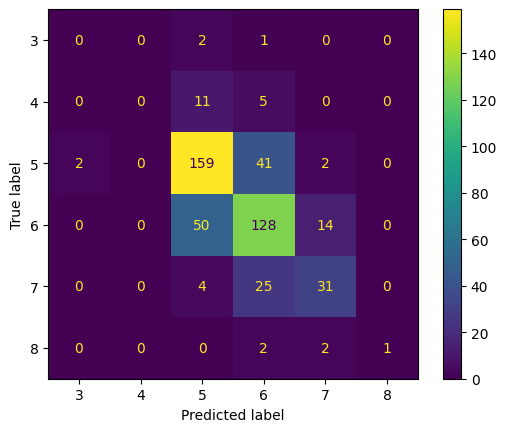

In [ ]:
model_params = {'classify__n_estimators': randint(50,500),
              'classify__max_depth': randint(1,20),
              'classify__min_samples_split': randint(2, 10),
              'classify__min_samples_leaf': randint(1, 10)
              }

pipeline = Pipeline(
    steps=[("preprocess", StandardScaler()),
           ("classify", RandomForestClassifier(random_state=5))]
)

n_iter = 20
random_search = RandomizedSearchCV(pipeline,
                                   param_distributions=model_params, 
                                   n_iter=n_iter, verbose=3)


random_search.fit(X_train, y_train)
best_rf = random_search.best_estimator_

print('Best hyperparameters:',  random_search.best_params_)
print(f"Best cross-validation score: {random_search.best_score_}")

print(f"Training accuracy = {best_rf.score(X_train, y_train)}")
print('Training Classification Report')
print(classification_report(y_train, best_rf.predict(X_train)))
print('Test Confusion Matrix')
ConfusionMatrixDisplay.from_estimator(best_rf, X_train, y_train)
plt.show()

print(f"Test accuracy = {best_rf.score(X_test, y_test)}")
print('Test Classification Report')
print(classification_report(y_test, best_rf.predict(X_test)))
print('Test Confusion Matrix')
ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test)
plt.show()